# We hit the KPI and broke the business

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/guardrail-metric/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/guardrail-metric/demo.ipynb)

**A guardrail is not a second metric. It is a constraint, and a constraint has a power.**

Every experiment review has a checklist of counter-metrics. Somebody confirms none of them
moved, and the change ships. This notebook builds a world where the change is *definitely*
harmful, runs that checklist against it, and measures how often anything notices.

| # | question | the finding |
|---|---|---|
| 1 | What is the trade? | +12% conversion, -15% retention rate |
| 2 | Could the guardrail fire? | the experiment is powered 0.80 for the win, 0.33 for the harm |
| 3 | What does a clean tick mean? | a harmful change clears the checklist 23% of the time |
| 4 | Do more guardrails help? | adding a placebo raises false blocks and lowers detection |
| 5 | Can it be measured in time? | the best predictor has a denominator of exactly zero on day 14 |
| 6 | What does a year cost? | the slide reads +36%, the retention rate reads -10% |
| 7 | How is a guardrail chosen? | by correlation, which ranks almost independently of what makes it fire |
| 8 | What fixes it? | pool the same metrics into one index - free, and worth 5x the clever part |

Everything below runs from numpy and scipy with a fixed seed. Nothing is asserted that is
not computed in front of you.

## 1. A world where the answer is known

You cannot grade a guardrail against real data, because with real data nobody knows whether
the harm was there. So we write the harm down.

A growth lever has an intensity `a`. It does two things, and both are ordinary:

1. it buys **incremental conversions**, and those marginal users retain at 8% against the
   62% of an ordinary converter;
2. it makes the product pushier for **35% of everyone**, which costs them some retention.

The primary metric goes up. The business goes down. Both are true at the same time.

In [1]:
from __future__ import annotations
import numpy as np
from scipy import stats

P0, REL_LIFT, ANNOY_REACH = 0.10, 0.12, 0.35
R_GOOD, R_MARGINAL, ANNOY_HIT = 0.62, 0.08, 0.18
RESP_RATE = 0.02

def annoyed(a):      return ANNOY_REACH * a
def incremental(a):  return P0 * REL_LIFT * a
def conversion(a):   return P0 + incremental(a)
def primary_lift(a): return conversion(a) / P0 - 1.0

def true_value(a):
    """180-day retained users per 1,000 exposed."""
    return 1000.0 * (P0 * R_GOOD * (1 - ANNOY_HIT * annoyed(a)) + incremental(a) * R_MARGINAL)

def value_change(a):   return true_value(a) / true_value(0.0) - 1.0
def retention_rate(a): return true_value(a) / (1000.0 * conversion(a))
def rate_change(a):    return retention_rate(a) / retention_rate(0.0) - 1.0

print(f"{'intensity':>9} {'conversion':>11} {'reported lift':>14} {'retained/1k':>12} "
      f"{'volume':>8} {'ret. rate':>10} {'rate chg':>9}")
for a in [0.0, 0.25, 0.5, 0.75, 1.0]:
    print(f"{a:9.2f} {conversion(a):11.4f} {primary_lift(a)*100:13.1f}% {true_value(a):12.2f} "
          f"{value_change(a)*100:7.2f}% {retention_rate(a):10.4f} {rate_change(a)*100:8.2f}%")

intensity  conversion  reported lift  retained/1k   volume  ret. rate  rate chg
     0.00      0.1000           0.0%        62.00    0.00%     0.6200     0.00%
     0.25      0.1030           3.0%        61.26   -1.19%     0.5948    -4.07%
     0.50      0.1060           6.0%        60.53   -2.38%     0.5710    -7.90%
     0.75      0.1090           9.0%        59.79   -3.56%     0.5485   -11.53%
     1.00      0.1120          12.0%        59.05   -4.75%     0.5273   -14.96%


Note the two damage columns. Retained users per 1,000 fall **4.75%**; the retention *rate*
falls **14.96%** — three times as far. The aggregate hides the harm because the lever
inflates its denominator with precisely the users who will not retain.

A total can absorb a great deal of damage to a rate before it visibly moves. That is the
first reason the checklist is watching the wrong number.

In [2]:
print(f"volume change at a=1: {value_change(1.0)*100:.2f}%")
print(f"rate   change at a=1: {rate_change(1.0)*100:.2f}%")
print(f"the rate falls {rate_change(1.0)/value_change(1.0):.2f}x as far as the total")

volume change at a=1: -4.75%
rate   change at a=1: -14.96%
the rate falls 3.15x as far as the total


## 2. Nine guardrails, and one rule about maturity

Each guardrail below is a noisy, partially-matured view of one of the two mechanisms. Two
things decide whether it can fire: how hard the lever moves it, and **how many users have
existed long enough to have a value for it**.

Users enrol uniformly over the experiment, so a metric that needs `m` days of exposure is
observable for `(D - m)/D` of them. On day 14 a 90-day retention metric is observable for
exactly none of them. It is on the checklist. It cannot be computed.

In [3]:
def observable_fraction(D, m):
    return max(0.0, (D - m) / D) if D > 0 else 0.0

# name, family, channel, denominator, maturity, control, effect, sd, harm_sign
GUARDRAILS = [
    ("refund_rate",         "binom",   "marginal", "converters",  3, 0.0200, 0.0900, 0.0,   +1),
    ("d7_retention",        "binom",   "marginal", "converters",  7, 0.7800, 0.4000, 0.0,   -1),
    ("d90_retention",       "binom",   "marginal", "converters", 90, 0.6600, 0.1500, 0.0,   -1),
    ("unsubscribe_rate",    "binom",   "annoy",    "all",         2, 0.0080, 0.0040, 0.0,   +1),
    ("support_ticket_rate", "poisson", "annoy",    "all",         1, 0.0300, 0.0100, 0.0,   +1),
    ("complaint_rate",      "binom",   "annoy",    "all",         2, 0.0009, 0.0012, 0.0,   +1),
    ("nps_score",           "normal",  "annoy",    "responders",  5, 8.1000, 0.8000, 2.40,  -1),
    ("session_minutes",     "normal",  "annoy",    "all",         1, 12.400, 0.3000, 6.20,  -1),
    ("page_latency_ms",     "normal",  "none",     "all",         0, 820.00, 0.0000, 240.0, +1),
]
DASHBOARD = ["unsubscribe_rate", "support_ticket_rate", "complaint_rate",
             "nps_score", "session_minutes", "page_latency_ms"]

def treat_param(g, a):
    _, _, channel, _, _, base, effect, _, sign = g
    if channel == "marginal":
        inc = incremental(a)
        return (P0 * base + inc * effect) / (P0 + inc)
    if channel == "annoy":
        return base + annoyed(a) * effect * sign
    return base

def denom_n(g, a, n, D):
    _, _, _, denom, m, *_ = g
    f = observable_fraction(D, m)
    if denom == "all":        return n * f, n * f
    if denom == "responders": return n * RESP_RATE * f, n * RESP_RATE * f
    return n * P0 * f, n * conversion(a) * f

def analytic_z(g, a, n, D):
    name, family, _, _, _, base, _, sd, sign = g
    n_c, n_t = denom_n(g, a, n, D)
    if n_c < 1 or n_t < 1: return 0.0
    p_t = treat_param(g, a)
    if family == "binom":     se = np.sqrt(base*(1-base)/n_c + p_t*(1-p_t)/n_t)
    elif family == "poisson": se = np.sqrt(base/n_c + p_t/n_t)
    else:                     se = sd * np.sqrt(1/n_c + 1/n_t)
    return sign * (p_t - base) / se if se > 0 else 0.0

def analytic_power(g, a, n, D, alpha=0.05):
    n_c, n_t = denom_n(g, a, n, D)
    if n_c < 1 or n_t < 1: return float("nan")
    return 1 - stats.norm.cdf(stats.norm.ppf(1-alpha) - analytic_z(g, a, n, D))

## 3. The experiment is powered for the win, not for the harm

The sample size is chosen the way every sample size is chosen: enough to detect the lift
you hope for. Nobody computes a second one for the harm you hope to avoid — and at that
same `n`, on that same day, no guardrail in the catalogue gets close.

In [4]:
ALPHA, DAY = 0.05, 14

def primary_power(a, n, alpha=ALPHA):
    p_c, p_t = P0, conversion(a)
    se = np.sqrt(p_c*(1-p_c)/n + p_t*(1-p_t)/n)
    return 1 - stats.norm.cdf(stats.norm.ppf(1-alpha) - (p_t-p_c)/se)

def n_for_power(target, a, g=None, D=DAY, alpha=ALPHA, hi=400_000_000):
    f = (lambda n: primary_power(a, n, alpha)) if g is None else \
        (lambda n: (lambda p: 0.0 if np.isnan(p) else p)(analytic_power(g, a, n, D, alpha)))
    if f(hi) < target: return None
    lo = 1
    while lo < hi:
        mid = (lo + hi) // 2
        if f(mid) >= target: hi = mid
        else:                lo = mid + 1
    return lo

N = n_for_power(0.80, 1.0)
print(f"n per arm, sized for 80% power on the +12% WIN: {N:,}")
print(f"realised power on the win: {primary_power(1.0, N):.3f}\n")
print(f"{'guardrail':22} {'denominator':>11} {'z':>6} {'power':>18} {'n for 80%':>13}")
for g in GUARDRAILS:
    n_c, _ = denom_n(g, 1.0, N, DAY)
    p = analytic_power(g, 1.0, N, DAY)
    need = n_for_power(0.80, 1.0, g)
    tag = " (dashboard)" if g[0] in DASHBOARD else ""
    print(f"{g[0]:22} {n_c:11,.0f} {analytic_z(g,1.0,N,DAY):6.2f} "
          f"{('cannot be computed' if np.isnan(p) else f'{p:.3f}'):>18} "
          f"{('unreachable' if need is None else f'{need:,}'):>13}{tag}")

n per arm, sized for 80% power on the +12% WIN: 8,135
realised power on the win: 0.800

guardrail              denominator      z              power     n for 80%
refund_rate                    639   0.91              0.231        60,822
d7_retention                   407   1.40              0.404        25,638
d90_retention                    0   0.00 cannot be computed   unreachable
unsubscribe_rate             6,973   0.89              0.225        63,473 (dashboard)
support_ticket_rate          7,554   1.21              0.331        34,514 (dashboard)
complaint_rate               6,973   0.74              0.184        90,672 (dashboard)
nps_score                      105   0.84              0.212        70,658 (dashboard)
session_minutes              7,554   1.04              0.273        46,429 (dashboard)
page_latency_ms              8,135   0.00              0.050   unreachable (dashboard)


Read the last column. To notice the harm as reliably as the experiment notices the win,
`d7_retention` needs **3.2x** the sample and `support_ticket_rate` — the best metric that is
actually on the dashboard — needs **4.2x**. `page_latency_ms` is a placebo the lever provably
cannot touch, and it fires at exactly alpha: it is a coin.

And `d90_retention`, the metric that tracks the outcome most closely, has a denominator of
zero. `(14 - 90)` is negative. No user is old enough.

## 4. So what does a clean checklist actually tell you?

Let us simulate the experiment properly, at the sufficient-statistic level, and see how
often a **maximally harmful** change walks through the review untouched.

In [5]:
def simulate(a, n, D, reps, rng):
    inc, ann = incremental(a), annoyed(a)
    conv_c = rng.binomial(n, P0, reps).astype(float)
    good_t = rng.binomial(n, P0, reps).astype(float)
    marg_t = rng.binomial(n, inc, reps).astype(float) if inc > 0 else np.zeros(reps)
    ann_t  = rng.binomial(n, ann, reps).astype(float) if ann > 0 else np.zeros(reps)
    out = {}
    for g in GUARDRAILS:
        name, family, channel, denom, m, base, effect, sd, sign = g
        f = observable_fraction(D, m)
        if f <= 0:
            out[name] = np.full(reps, np.nan); continue
        if denom == "converters":
            n_c = np.floor(conv_c*f); n_g = np.floor(good_t*f); n_m = np.floor(marg_t*f)
            n_t = n_g + n_m
        elif denom == "responders":
            n_c = np.full(reps, np.floor(n*RESP_RATE*f)); n_t = n_c.copy()
            n_g = n_m = np.zeros(reps)
        else:
            n_c = np.full(reps, np.floor(n*f)); n_t = n_c.copy(); n_g = n_m = np.zeros(reps)

        if channel == "marginal":
            s_c = rng.binomial(n_c.astype(np.int64), base).astype(float)
            s_t = (rng.binomial(n_g.astype(np.int64), base)
                   + rng.binomial(n_m.astype(np.int64), effect)).astype(float)
        else:
            k_ann = (rng.binomial(n_t.astype(np.int64), ann) if denom == "responders" and ann > 0
                     else np.minimum(np.floor(ann_t*f), n_t)).astype(np.int64)
            k_pln = (n_t - k_ann).astype(np.int64)
            bump = base + effect*sign
            if family == "binom":
                s_c = rng.binomial(n_c.astype(np.int64), base).astype(float)
                s_t = (rng.binomial(k_pln, base)
                       + rng.binomial(k_ann, min(max(bump,0.0),1.0))).astype(float)
            elif family == "poisson":
                s_c = rng.poisson(n_c*base).astype(float)
                s_t = (rng.poisson(k_pln*base) + rng.poisson(k_ann*max(bump,0.0))).astype(float)
            else:
                mu = np.where(n_t>0, (k_pln*base + k_ann*bump)/np.maximum(n_t,1), base)
                s_c = base*n_c + rng.normal(0,sd,reps)*np.sqrt(np.maximum(n_c,1e-9))
                s_t = mu*n_t   + rng.normal(0,sd,reps)*np.sqrt(np.maximum(n_t,1e-9))

        n_c = np.maximum(n_c,1e-9); n_t = np.maximum(n_t,1e-9)
        p_c, p_t = s_c/n_c, s_t/n_t
        if family == "binom":
            pool = (s_c+s_t)/(n_c+n_t); se = np.sqrt(np.maximum(pool*(1-pool),1e-12)*(1/n_c+1/n_t))
        elif family == "poisson":
            pool = (s_c+s_t)/(n_c+n_t); se = np.sqrt(np.maximum(pool,1e-12)*(1/n_c+1/n_t))
        else:
            se = sd*np.sqrt(1/n_c+1/n_t)
        out[name] = sign*(p_t-p_c)/np.maximum(se,1e-12)
    return out

def any_fires(z, suite, alpha):
    crit = stats.norm.ppf(1-alpha)
    hit = np.zeros(len(next(iter(z.values()))), dtype=bool)
    for s in suite:
        hit |= np.nan_to_num(z[s], nan=-np.inf) > crit
    return hit

rng = np.random.default_rng(20260830)
z1 = simulate(1.0, N, DAY, 20000, rng)   # a maximally harmful change
z0 = simulate(0.0, N, DAY, 20000, rng)   # a completely harmless one
ALL = [g[0] for g in GUARDRAILS if g[0] != "d90_retention"]

print(f"A HARMFUL change clears the dashboard checklist:  {1-any_fires(z1, DASHBOARD, ALPHA).mean():.3f}")
print(f"A HARMLESS change clears the dashboard checklist: {1-any_fires(z0, DASHBOARD, ALPHA).mean():.3f}")
print(f"\nsanity: every guardrail holds its false-positive rate under the null")
for g in GUARDRAILS:
    if np.all(np.isnan(z0[g[0]])): continue
    print(f"  {g[0]:22} {np.mean(z0[g[0]] > stats.norm.ppf(1-ALPHA)):.4f}")

A HARMFUL change clears the dashboard checklist:  0.235
A HARMLESS change clears the dashboard checklist: 0.734

sanity: every guardrail holds its false-positive rate under the null
  refund_rate            0.0483
  d7_retention           0.0512
  unsubscribe_rate       0.0518
  support_ticket_rate    0.0483
  complaint_rate         0.0520
  nps_score              0.0479
  session_minutes        0.0515
  page_latency_ms        0.0476


A harmful change clears the checklist **23%** of the time and a harmless one clears it
**73%** of the time. Those two numbers are what a tick is worth: it is not nothing, but it is
nowhere near the confidence the review treats it as.

And the honest version of "no significant change" is not "no harm" — it is **"not measured"**.
To actually *prove* the harm is smaller than a stated bound takes about **66x** the sample.

In [6]:
g7 = dict((g[0], g) for g in GUARDRAILS)["d7_retention"]
crit = stats.norm.ppf(1-ALPHA)
need = next(N*m for m in range(1,400)
            if 1-stats.norm.cdf(crit - analytic_z(g7, 0.20, N*m, DAY)) >= 0.80)
print(f"to PROVE harm is under the intensity-0.2 bound, 80% of the time: {need:,} per arm "
      f"({need/N:.0f}x the experiment)")

to PROVE harm is under the intensity-0.2 bound, 80% of the time: 536,910 per arm (66x the experiment)


## 5. Adding guardrails does not add safety

The obvious response is *more counter-metrics*. Here is what each one costs, both ways —
including a placebo that the lever provably cannot move.

In [7]:
order = DASHBOARD + ["refund_rate", "d7_retention"]
print(f"{'k':>2} {'added':22} {'false block':>12} {'detects harm':>13} {'bonf detect':>12}")
for k in range(1, len(order)+1):
    s = order[:k]
    print(f"{k:2d} {order[k-1]:22} {any_fires(z0,s,ALPHA).mean():11.3f} "
          f"{any_fires(z1,s,ALPHA).mean():12.3f} {any_fires(z1,s,ALPHA/k).mean():11.3f}")

k = len(order)
print(f"\nobserved false-block rate {any_fires(z0,order,ALPHA).mean():.4f}")
print(f"1 - (1-0.05)^{k}          = {1-0.95**k:.4f}   <- these guardrails are near-independent,")
print("so every one you add multiplies the chance something harmless trips.")

 k added                   false block  detects harm  bonf detect
 1 unsubscribe_rate             0.052        0.225       0.225
 2 support_ticket_rate          0.098        0.484       0.334
 3 complaint_rate               0.145        0.577       0.326
 4 nps_score                    0.187        0.662       0.330
 5 session_minutes              0.229        0.753       0.359
 6 page_latency_ms              0.266        0.765       0.329
 7 refund_rate                  0.302        0.820       0.343
 8 d7_retention                 0.338        0.891       0.405

observed false-block rate 0.3377
1 - (1-0.05)^8          = 0.3366   <- these guardrails are near-independent,
so every one you add multiplies the chance something harmless trips.


Adding `page_latency_ms` — a metric with *zero* causal sensitivity — raises the false-block
rate and, once you correct for the size of the suite, **lowers** detection of real harm. A
guardrail with no sensitivity is not free.

The dilemma is real and has no clean fix: uncorrected, the suite blocks a third of harmless
changes. Corrected, detection of a maximally harmful change collapses from 0.89 to 0.40.
Both are consequences of running many underpowered tests instead of one powered one.

## 6. How guardrails get chosen, and why that is the wrong axis

In practice somebody correlates every available metric against churn and picks the top of
the list. But correlating with the outcome and *responding to the lever* are different
properties, and only the second one makes a guardrail fire.

In [8]:
LOADING = {"refund_rate":0.45, "d7_retention":1.30, "d90_retention":1.75, "unsubscribe_rate":0.70,
           "support_ticket_rate":0.35, "complaint_rate":0.30, "nps_score":1.10,
           "session_minutes":2.05, "page_latency_ms":0.00}

def passive_cohort(n_users, rng):
    """Observational data. Nothing here is causal."""
    e = rng.normal(0, 1, n_users)
    retained = (rng.random(n_users) <
                1/(1+np.exp(-(np.log(R_GOOD/(1-R_GOOD)) + 1.15*e)))).astype(float)
    vals = {}
    for g in GUARDRAILS:
        name, family, _, _, _, base, _, sd, sign = g
        sig = -sign * LOADING[name] * e
        if family == "normal":    vals[name] = base + sig*(sd/3) + rng.normal(0,sd,n_users)
        elif family == "poisson": vals[name] = rng.poisson(base*np.exp(sig)).astype(float)
        else:
            odds = np.log(base/(1-base)) + sig
            vals[name] = (rng.random(n_users) < 1/(1+np.exp(-odds))).astype(float)
    return vals, retained

vals, retained = passive_cohort(300_000, np.random.default_rng(5))
rows = [(g[0], abs(np.corrcoef(vals[g[0]], retained)[0,1]), analytic_z(g,1.0,N,DAY),
         observable_fraction(DAY, g[4]) > 0) for g in GUARDRAILS]
rho, p = stats.spearmanr([r[1] for r in rows], [r[2] for r in rows])

print(f"{'guardrail':22} {'|corr| w/ outcome':>18} {'causal z':>9} {'runnable day 14':>16}")
for r in sorted(rows, key=lambda r: -r[1]):
    print(f"{r[0]:22} {r[1]:18.4f} {r[2]:9.2f} {('yes' if r[3] else 'NO'):>16}")
print(f"\nSpearman(correlation, causal sensitivity) = {rho:+.3f}  (p = {p:.3f})")

guardrail               |corr| w/ outcome  causal z  runnable day 14
d90_retention                      0.2649      0.00               NO
session_minutes                    0.2548      1.04              yes
d7_retention                       0.2117      1.40              yes
nps_score                          0.1545      0.84              yes
unsubscribe_rate                   0.0350      0.89              yes
refund_rate                        0.0294      0.91              yes
support_ticket_rate                0.0268      1.21              yes
complaint_rate                     0.0051      0.74              yes
page_latency_ms                    0.0035      0.00              yes

Spearman(correlation, causal sensitivity) = +0.201  (p = 0.604)


The metric an analyst picks first is `d90_retention` — and on decision day it **cannot be
measured at all**. The metric with the most causal sensitivity, `d7_retention`, is third by
correlation. The rank correlation between the two is not distinguishable from zero at
n = 9 metrics, which is the point: the axis a guardrail is chosen on carries almost no
information about the axis that makes it useful.

## 7. What actually fixes it (and it is free)

Nine underpowered tests can be replaced by **one** test on a directional index built from the
same nine numbers. No new instrumentation, no longer window, no bigger sample — just
stopping the practice of testing them one at a time.

In [9]:
def composite(z, suite, weights=None):
    cols, ws = [], []
    for s in suite:
        if np.all(np.isnan(z[s])): continue
        w = 1.0 if weights is None else weights.get(s, 0.0)
        if w == 0: continue
        cols.append(np.nan_to_num(z[s], nan=0.0)); ws.append(w)
    A, w = np.vstack(cols), np.array(ws)
    return (w @ A) / np.sqrt((w**2).sum())

gd = dict((g[0], g) for g in GUARDRAILS)
W = {s: max(analytic_z(gd[s], 1.0, N, DAY), 0.0) for s in ALL}

for label, a in [("maximally harmful (a = 1.0)", 1.0), ("an ordinary change (a = 0.4)", 0.4)]:
    za = simulate(a, N, DAY, 20000, np.random.default_rng(99))
    fb = any_fires(z0, ALL, ALPHA).mean()                       # match the false-block rate
    crit_eq = np.quantile(composite(z0, ALL), 1-fb)
    crit_w  = np.quantile(composite(z0, ALL, W), 1-fb)
    print(f"{label}   (all policies block {fb:.1%} of harmless changes)")
    print(f"  {len(ALL)} separate tests        detect {any_fires(za, ALL, ALPHA).mean():.3f}")
    print(f"  one index, equal weights  detect {np.mean(composite(za, ALL) > crit_eq):.3f}")
    print(f"  one index, sens-weighted  detect {np.mean(composite(za, ALL, W) > crit_w):.3f}\n")

maximally harmful (a = 1.0)   (all policies block 33.8% of harmless changes)
  8 separate tests        detect 0.890
  one index, equal weights  detect 0.981
  one index, sens-weighted  detect 0.989

an ordinary change (a = 0.4)   (all policies block 33.8% of harmless changes)
  8 separate tests        detect 0.578
  one index, equal weights  detect 0.728
  one index, sens-weighted  detect 0.760



Two things worth noticing.

At **a = 1.0** the separate tests already do well, because a maximally harmful change is loud.
The gap opens at **a = 0.4** — the ordinary, unremarkable change that gets shipped most often
and does most of the cumulative damage.

And the **cheap half of the idea does nearly all the work**. Pooling with equal weights needs
nothing you do not already have. Sensitivity weighting needs an estimate of how hard the
lever moves each metric, which is exactly the thing nobody has — and in the full study it is
worth about a fifth as much as the free part.

## 8. The picture

Two panels: what each guardrail could possibly detect, and what a 14-day window can even see.

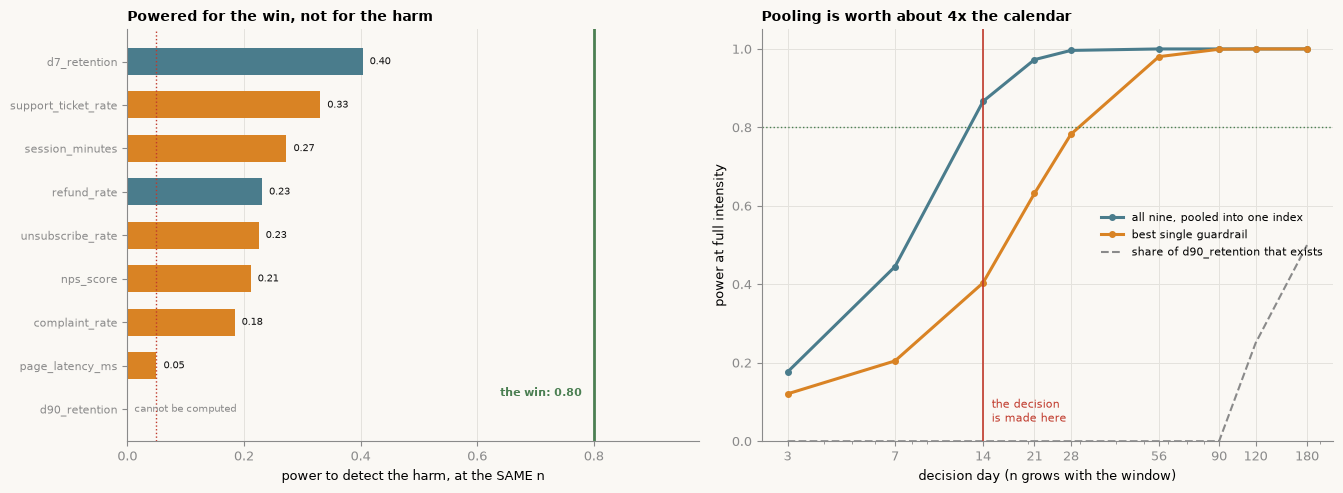

In [10]:
import matplotlib.pyplot as plt

INK, MUTED, GRID, PAPER = "#141414", "#8a8a8a", "#e4e2dd", "#faf8f4"
RED, ORANGE, BLUE, GREEN = "#c0392b", "#d98324", "#4a7c8c", "#4b7f52"
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": PAPER, "axes.facecolor": PAPER,
                     "axes.edgecolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.0))

rows2 = sorted([(g[0], 0.0 if np.isnan(analytic_power(g,1.0,N,DAY)) else analytic_power(g,1.0,N,DAY),
                 np.isnan(analytic_power(g,1.0,N,DAY)), g[0] in DASHBOARD) for g in GUARDRAILS],
               key=lambda r: r[1])
y = np.arange(len(rows2))
ax1.barh(y, [r[1] for r in rows2], height=0.62,
         color=[MUTED if r[2] else (ORANGE if r[3] else BLUE) for r in rows2])
ax1.set_yticks(y); ax1.set_yticklabels([r[0] for r in rows2], fontsize=8)
ax1.axvline(primary_power(1.0, N), color=GREEN, lw=2)
ax1.text(primary_power(1.0,N)-0.02, 0.3, "the win: 0.80", color=GREEN, ha="right", fontweight="bold", fontsize=8)
ax1.axvline(ALPHA, color=RED, lw=1, ls=":")
for i, r in enumerate(rows2):
    ax1.text(r[1]+0.012, i, "cannot be computed" if r[2] else f"{r[1]:.2f}",
             va="center", fontsize=7.5, color=MUTED if r[2] else INK)
ax1.set_xlim(0, 0.98); ax1.set_xlabel("power to detect the harm, at the SAME n")
ax1.set_title("Powered for the win, not for the harm", loc="left", fontweight="bold", fontsize=10)
ax1.grid(axis="x", color=GRID, lw=0.7); ax1.set_axisbelow(True)

days = [3, 7, 14, 21, 28, 56, 90, 120, 180]
best, comp, d90 = [], [], []
for D in days:
    n = int(N/14*D)
    live = [g[0] for g in GUARDRAILS if observable_fraction(D, g[4]) > 0]
    w = {s: max(analytic_z(gd[s],1.0,n,D),0.0) for s in live}
    r0 = simulate(0.0, n, D, 4000, np.random.default_rng(7+D))
    r1 = simulate(1.0, n, D, 4000, np.random.default_rng(8+D))
    c = np.quantile(composite(r0, live, w), 1-ALPHA)
    comp.append(np.mean(composite(r1, live, w) > c))
    best.append(max(analytic_power(gd[s],1.0,n,D) for s in live))
    d90.append(observable_fraction(D, 90))
ax2.plot(days, comp, color=BLUE, lw=2.2, marker="o", ms=4, label="all nine, pooled into one index")
ax2.plot(days, best, color=ORANGE, lw=2.2, marker="o", ms=4, label="best single guardrail")
ax2.plot(days, d90, color=MUTED, lw=1.5, ls="--", label="share of d90_retention that exists")
ax2.axhline(0.80, color=GREEN, lw=1, ls=":"); ax2.axvline(14, color=RED, lw=1.2)
ax2.text(15, 0.05, "the decision\nis made here", color=RED, fontsize=8)
ax2.set_xscale("log"); ax2.set_xticks(days); ax2.set_xticklabels(days)
ax2.set_xlabel("decision day (n grows with the window)"); ax2.set_ylabel("power at full intensity")
ax2.set_ylim(0, 1.05); ax2.legend(frameon=False, fontsize=8, loc="center right")
ax2.set_title("Pooling is worth about 4x the calendar", loc="left", fontweight="bold", fontsize=10)
ax2.grid(color=GRID, lw=0.7); ax2.set_axisbelow(True)

plt.tight_layout(); plt.savefig("guardrail_notebook.png", dpi=150); plt.show()

## 9. A year of experiments that all passed

One ship is survivable. The argument is about what twenty of them do — especially since
reaching significance on the *win* requires the aggressive version of the change, so the ship
filter actively selects **for** harm.

In [11]:
YEARS, PER_YEAR, CLEAN_SHARE = 800, 20, 0.60
grid = np.round(np.arange(0, 1.001, 0.05), 3)
pool = {float(a): simulate(float(a), N, DAY, 3000, np.random.default_rng(500+i))
        for i, a in enumerate(grid)}
pool_p = {float(a): simulate(float(a), N, DAY, 3000, np.random.default_rng(500+i))
          for i, a in enumerate(grid)}

def primary_z_lift(lift, n):
    p_c, p_t = P0, P0*(1+lift)
    return (p_t-p_c)/np.sqrt(p_c*(1-p_c)/n + p_t*(1-p_t)/n)

def run_year(policy, seed=4):
    rng = np.random.default_rng(seed)
    tot = YEARS*PER_YEAR
    clean = rng.random(tot) < CLEAN_SHARE
    lift_c = rng.uniform(0, 0.12, tot)
    a = rng.uniform(0, 1, tot)
    bins = np.round(a/0.05)*0.05
    zg = {s: np.empty(tot) for s in ALL}
    zp = np.empty(tot)
    for b in grid:
        m = (~clean) & np.isclose(bins, b)
        k = int(m.sum())
        if k:
            idx = rng.integers(0, 3000, k)
            for s in ALL: zg[s][m] = pool[float(b)][s][idx]
            conv_c = rng.binomial(N, P0, k); conv_t = rng.binomial(N, conversion(b), k)
            pl = (conv_c+conv_t)/(2*N)
            zp[m] = (conv_t-conv_c)/N/np.maximum(np.sqrt(pl*(1-pl)*2/N), 1e-12)
    m = clean; k = int(m.sum()); idx = rng.integers(0, 3000, k)
    for s in ALL: zg[s][m] = pool[0.0][s][idx]
    zp[m] = rng.normal([primary_z_lift(x, N) for x in lift_c[m]], 1.0)

    shipped = (zp > stats.norm.ppf(1-ALPHA)) & ~policy(zg)
    lift = np.where(clean, lift_c, [primary_lift(x) for x in a])
    dq   = np.where(clean, 0.0,    [rate_change(x) for x in a])
    L = (lift*shipped).reshape(YEARS, PER_YEAR).sum(axis=1).mean()
    Q = np.prod(1+np.where(shipped, dq, 0.0).reshape(YEARS, PER_YEAR), axis=1).mean()
    return shipped.sum()/YEARS, L, Q-1, a[shipped & ~clean].mean(), a[~clean].mean()

W2 = {s: max(analytic_z(gd[s],1.0,N,DAY),0.0) for s in ALL}
crit_c = np.quantile(composite(z0, ALL, W2), 1-ALPHA)
print(f"{'policy':20} {'ships/yr':>9} {'reported lift':>14} {'180d retention rate':>21}")
for label, pol in [("no guardrail",   lambda z: np.zeros(len(z[ALL[0]]), dtype=bool)),
                   ("dashboard suite",lambda z: any_fires(z, DASHBOARD, ALPHA)),
                   ("composite index",lambda z: composite(z, ALL, W2) > crit_c)]:
    ships, L, Q, sa, pa = run_year(pol)
    print(f"{label:20} {ships:9.2f} {L*100:13.1f}% {Q*100:20.2f}%")
    if label == "dashboard suite":
        print(f"{'':20} {'':9} mean intensity PROPOSED {pa:.2f} -> mean intensity SHIPPED {sa:.2f}")

policy                ships/yr  reported lift   180d retention rate
no guardrail              7.62          62.4%               -27.71%
dashboard suite           4.46          35.4%               -10.86%
                               mean intensity PROPOSED 0.50 -> mean intensity SHIPPED 0.61
composite index           5.68          44.4%               -10.43%


The slide adds up to a large positive year. The retention rate does not. Both numbers come
from the same shipped experiments, and **every one of those experiments passed its guardrails.**

The shipped intensity is higher than the proposed intensity, every time. That is not bad
luck — significance on the win requires the aggressive version, so the filter that decides
what ships is correlated with the thing the guardrail is supposed to catch.

## 10. What a guardrail has to carry

A counter-metric is not a guardrail until somebody can answer these about it:

1. **A threshold it could actually cross.** If nobody computed its power, the tick is
   measuring the sample size, not the product.
2. **A denominator that exists on decision day.** Maturity is arithmetic, not diligence.
3. **Sensitivity to the lever, not correlation with the outcome.** They rank almost
   independently.
4. **A margin, not a null.** "Not significant" means "not measured" until a bound is stated
   and cleared.
5. **One test, not nine.** Pooling is free and beats splitting at a matched false-block rate.
6. **Its own alpha, set by its own power.** 0.05 is not wrong everywhere — it is unexamined
   everywhere.
7. **A year-end number.** One ship is survivable. Twenty compound.

## Try your own

Change the world and see which conclusions survive. Some of them are robust; at least one
is not, and finding out which is the exercise.

In [12]:
# --- 1. Make the harm subtler. Does anything still fire?
# ANNOY_REACH = 0.15
# print({g[0]: round(float(analytic_power(g, 1.0, N, DAY)), 3) for g in GUARDRAILS})

# --- 2. Give the team a guardrail that is actually powered. What does it cost?
# for mult in [1, 2, 4, 8, 16]:
#     print(mult, round(float(analytic_power(gd["d7_retention"], 1.0, N*mult, DAY)), 3))

# --- 3. Add your own counter-metric and see where it lands on BOTH axes.
#        (name, family, channel, denominator, maturity, control, effect, sd, harm_sign)
# mine = ("checkout_errors", "binom", "annoy", "all", 1, 0.004, 0.003, 0.0, +1)
# print("causal z:", round(analytic_z(mine, 1.0, N, DAY), 2),
#       "power:",    round(float(analytic_power(mine, 1.0, N, DAY)), 3))

# --- 4. The claim most worth attacking: is pooling still better if the guardrails are
#        strongly CORRELATED rather than near-independent? Correlation is what makes a
#        composite lose its edge. Try adding three copies of one metric to ALL and rerun
#        the section 7 comparison.

---

**Day 160 of [Phoebe's FDE portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — one small, real tool a day.

- Full ten-section study: `python evidence.py`
- The engine, with 31 tests pinning every number: `guardrails.py`, `test_guardrails.py`
- Interactive version: `streamlit run app.py`

The notebook above re-implements a compact copy of the engine so it runs standalone on
Colab. `guardrails.py` in the repo is the authoritative one.